# imports

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.15f' % x)  # Exibe 5 casas decimais

In [3]:
shapefile_path = '/Volumes/ssd/Doutorado/DATASET/classify_slums/slum_variables.shp'
gdf = gpd.read_file(shapefile_path)

In [4]:
gdf = gdf[~gdf['wtr_pipe'].isna()]

In [6]:
# columns to normalize
columns_to_normalize = [
    'wtr_pipe', 'wtr_semi', 'no_wtr_pip', 'wtr_dist', 'wtr_deep', 'wtr_shal', 'wtr_spring', 'wtr_truck', 'wtr_rain', 'wtr_river', 'wtr_oth',
    'sanit_1', 'sanit_2', 'sanit_3', 'sanit_4', 'sanit_5', 'sanit_6', 'sanit_7', 'no_bath', 'excl_bath', 'shrd_bath', 'toilet',
    'hh_type_1', 'hh_type_2', 'hh_type_3', 'hh_type_4', 'hh_type_5', 'hh_type_6'
]
gdf[columns_to_normalize] = gdf[columns_to_normalize].apply(lambda x: x / 100)


# Funções de criação de índices

### Versão Exponencial 2
![Exp 2](../../exp_formula_2.png)

In [7]:
base = 2
def calc_exp_index(arr):
    cols = len(arr)
    index = 0
    for col in range(cols):
        index += arr[col] * (base ** col)
    return index

# Índices

In [8]:
exp_df_inv = pd.DataFrame()

scaler = MinMaxScaler()

## Improved Water

### maior indice = "melhor"

In [9]:
# Exponential
wtr_infra_score_exp = gdf.apply(
    lambda row: calc_exp_index([
        row['wtr_semi'] + row['no_wtr_pip'],
        row['wtr_pipe'],
    ]),
    axis=1
)

wtr_source_score_exp = gdf.apply(
    lambda row: calc_exp_index([
        row['wtr_deep'] + row['wtr_shal'] + row['wtr_spring'] + row['wtr_truck'] + row['wtr_rain'] + row['wtr_river'] + row['wtr_oth'],
        row['wtr_dist'],
    ]),
    axis=1
)

exp_df_inv['wtr_idx'] = (wtr_infra_score_exp + wtr_source_score_exp) / 2
exp_df_inv['wtr_idx'] = scaler.fit_transform(exp_df_inv[['wtr_idx']])


## Improved Sanitation

### maior indice = "melhor"

In [10]:
# Exponential
sanit_type_exp = gdf.apply(
    lambda row: calc_exp_index([
        row['sanit_5'] + row['sanit_6'] + row['sanit_7'] + row['no_bath'],
        row['sanit_2'] + row['sanit_3'] + row['sanit_4'],
        row['sanit_1'],
    ]),
    axis=1
)

sanit_bath_exp = gdf.apply(
    lambda row: calc_exp_index([
        row['shrd_bath'] + row['toilet'],
        row['excl_bath'],
    ]),
    axis=1
)

exp_df_inv['sanit_idx'] = (sanit_type_exp + sanit_bath_exp) / 2
exp_df_inv['sanit_idx'] = scaler.fit_transform(exp_df_inv[['sanit_idx']])

## Sufficient living area

In [12]:
# Depois de normalizar com o z-score, definir 3 categorias:
# 1: menor que a mediana
# 2: maior que a mediana e menor que o 3o quartil
# 3. maior que o terceiro quartil

mean_hh = gdf['hh_density'].mean()
std_hh = gdf['hh_density'].std()

mean_pop = gdf['demo_dens'].mean()
std_pop = gdf['demo_dens'].std()

z_hh = (gdf['hh_density'] - mean_hh) / std_hh
z_pop = (gdf['demo_dens'] - mean_pop) / std_pop

med_hh, q3_hh   = z_hh.median(),  z_hh.quantile(0.75)
med_pop, q3_pop = z_pop.median(), z_pop.quantile(0.75)

hh_cat  = np.select([z_hh < med_hh,  z_hh > q3_hh],  [1, 3], default=2)
pop_cat = np.select([z_pop < med_pop, z_pop > q3_pop],[1, 3], default=2)

living_area_idx = (hh_cat * z_hh) + (pop_cat * z_pop)
living_area_idx = scaler.fit_transform(living_area_idx.values.reshape(-1, 1))

# linear_df['living_area_idx'] = living_area_idx
# exp_df['living_area_idx'] = living_area_idx
# # inverse of living_area_idx
exp_df_inv['living_area_idx'] = 1 - living_area_idx


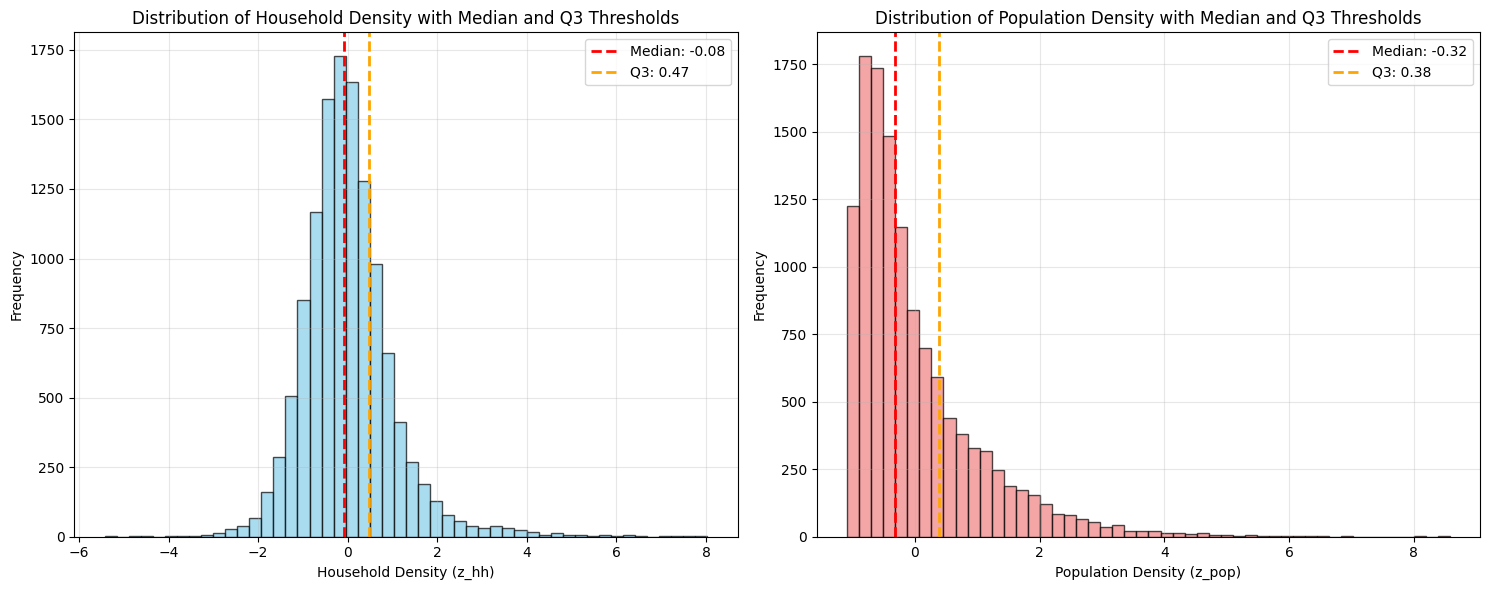

In [13]:
# plot charts with hh_dens and pop_dens distributions with median and Q3 lines
import matplotlib.pyplot as plt
import numpy as np

# Create subplots for both distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot the distribution of hh_dens
ax1.hist(z_hh, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(med_hh, color='red', linestyle='--', linewidth=2, label=f'Median: {med_hh:.2f}')
ax1.axvline(q3_hh, color='orange', linestyle='--', linewidth=2, label=f'Q3: {q3_hh:.2f}')
ax1.set_xlabel('Household Density (z_hh)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Household Density with Median and Q3 Thresholds')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot the distribution of pop_dens
ax2.hist(z_pop, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
ax2.axvline(med_pop, color='red', linestyle='--', linewidth=2, label=f'Median: {med_pop:.2f}')
ax2.axvline(q3_pop, color='orange', linestyle='--', linewidth=2, label=f'Q3: {q3_pop:.2f}')
ax2.set_xlabel('Population Density (z_pop)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Population Density with Median and Q3 Thresholds')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()


## Durable house

### maior indice = "melhor"

In [14]:
exp_df_inv['durable_house_idx'] = gdf.apply(
    lambda row: calc_exp_index([
        row['hh_type_4'] + row['hh_type_5'] + row['hh_type_6'],
        row['hh_type_1'] + row['hh_type_2'] + row['hh_type_3'],
    ]),
    axis=1
)
exp_df_inv['durable_house_idx'] = scaler.fit_transform(exp_df_inv[['durable_house_idx']])

In [17]:
exp_df_inv

,wtr_idx,sanit_idx,living_area_idx,durable_house_idx
0,1.000000000000000,0.756214953271028,0.921466469745383,0.999800039992001
1,0.940352982350882,0.538084112149533,0.873223101368211,0.999800039992001
2,0.604269786510674,0.503551401869159,0.678693029095104,0.999800039992001
3,0.516024198790061,0.487780373831776,0.747914289753038,0.980603879224155
4,0.285585720713964,0.379696261682243,0.756353198405033,0.999800039992002
...,...,...,...,...
12343,0.512874356282186,0.551308411214953,0.811418787368366,0.999400119976004
12344,0.934753262336883,0.505700934579439,0.875082791910804,0.999800039992001
12345,0.476926153692315,0.528457943925234,0.857311923660206,0.999800039992001
12346,0.991200439978001,0.532733644859813,0.866169698634362,0.949910017996400


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

features = [
    'wtr_idx',
    'sanit_idx',
    'living_area_idx',
    'durable_house_idx'
]

cluster_col = 'cluster_3'

centroids = (
    exp_df_inv
    .groupby(cluster_col)[features]
    .mean()
)

def distance_to_centroid(row):
    cluster = row[cluster_col]
    point = row[features].values.reshape(1, -1)
    centroid = centroids.loc[cluster].values.reshape(1, -1)
    return cdist(point, centroid, metric='euclidean')[0, 0]

exp_df_inv['dist_to_centroid'] = exp_df_inv.apply(
    distance_to_centroid, axis=1
)

plt.figure(figsize=(7, 4))
exp_df_inv.boxplot(
    column='dist_to_centroid',
    by=cluster_col,
    grid=False
)
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.violinplot(
    data=exp_df_inv,
    x=cluster_col,
    y='dist_to_centroid',
    inner='quartile'
)
plt.title('Distance to centroid by cluster')
plt.xlabel('Cluster')
plt.ylabel('Euclidean distance')
plt.show()

KeyError: 'cluster_3'

# Clusters

### calc

In [18]:
def create_clusters(gdf, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    arr = np.array(gdf)
    cluster_labels = kmeans.fit_predict(arr)
    gdf[f'cluster_{k}'] = cluster_labels
    return gdf

In [19]:
# exponential index inverse
exp_df_inv = create_clusters(exp_df_inv, 3)


In [20]:
# Swap cluster labels: 1 <-> 0, 2 stays the same
exp_df_inv['cluster_3'] = exp_df_inv['cluster_3'].replace({1: 0, 0: 1, 2: 2})


In [22]:
features

Index(['durable_house_idx', 'living_area_idx', 'sanit_idx', 'wtr_idx'], dtype='object')

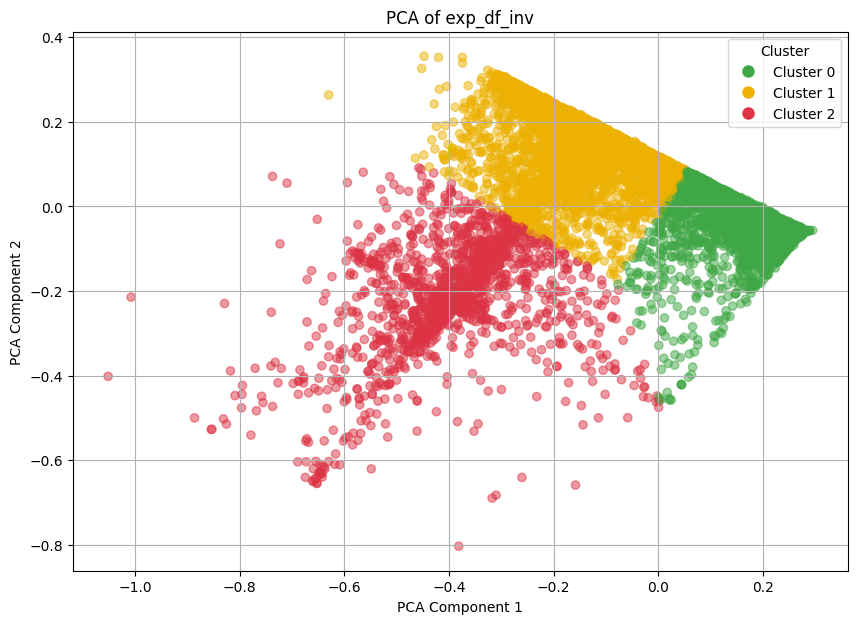

In [21]:
cluster_colors = {0: '#3fa745', 1: '#ecb102', 2: '#dc3444'}

# Plot PCA of exp_df_inv using cluster_colors
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select feature columns (excluding cluster column)
features = exp_df_inv.columns.difference(['cluster_3'])
X = exp_df_inv[features].values
y = exp_df_inv['cluster_3'].values

# Fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Map cluster labels to colors using cluster_colors
colors = exp_df_inv['cluster_3'].map(cluster_colors)

plt.figure(figsize=(10,7))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=colors, alpha=0.5)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of exp_df_inv')

# Create a custom legend using cluster_colors
handles = [
    plt.Line2D([], [], marker='o', color='w', markerfacecolor=cluster_colors[c], label=f"Cluster {c}", markersize=10)
    for c in sorted(cluster_colors)
]
plt.legend(handles=handles, title="Cluster")

plt.grid(True)
plt.show()

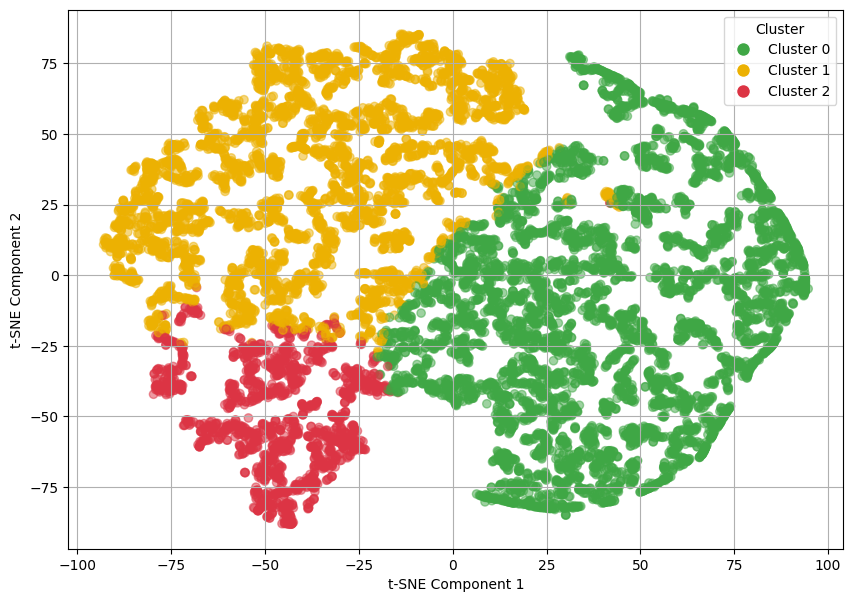

In [23]:
cluster_colors = {0: '#3fa745', 1: '#ecb102', 2: '#dc3444'}


# Plot t-SNE of exp_df_inv usando as cores do cluster_colors
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Usar as mesmas cores do cluster_colors já definidas
colors = exp_df_inv['cluster_3'].map(cluster_colors)

# Select feature columns (excluding cluster column)
features = exp_df_inv.columns.difference(['cluster_3'])
X = exp_df_inv[features].values
y = exp_df_inv['cluster_3'].values

# Fit t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10,7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.5)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
# plt.title('t-SNE of ')

# Criar custom legend usando as cores do cluster_colors
handles = [
    plt.Line2D([], [], marker='o', color='w', markerfacecolor=cluster_colors[c], label=f"Cluster {c}", markersize=10)
    for c in sorted(cluster_colors)
]
plt.legend(handles=handles, title="Cluster")

plt.grid(True)
plt.show()


In [14]:
def create_radar_chart(df, cluster_cols):
    indices = df.columns.difference(cluster_cols).tolist()
    num_vars = len(indices)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Fechar a teia

    fig, axes = plt.subplots(1, len(cluster_cols), figsize=(5 * len(cluster_cols), 5), subplot_kw=dict(polar=True))

    if len(cluster_cols) == 1:
        axes = [axes]

    for ax, cluster_col in zip(axes, cluster_cols):
        cluster_means = df.groupby(cluster_col)[indices].mean()
        normalized_profiles = cluster_means

        for idx, row in normalized_profiles.iterrows():
            values = row.tolist() + [row.tolist()[0]]
            ax.plot(angles, values, label=f'Cluster {idx}')
            ax.fill(angles, values, alpha=0.1)

        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_thetagrids(np.degrees(angles[:-1]), indices)
        ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=8)

    plt.subplots_adjust(wspace=0.5)
    plt.tight_layout()
    plt.show()

### viz

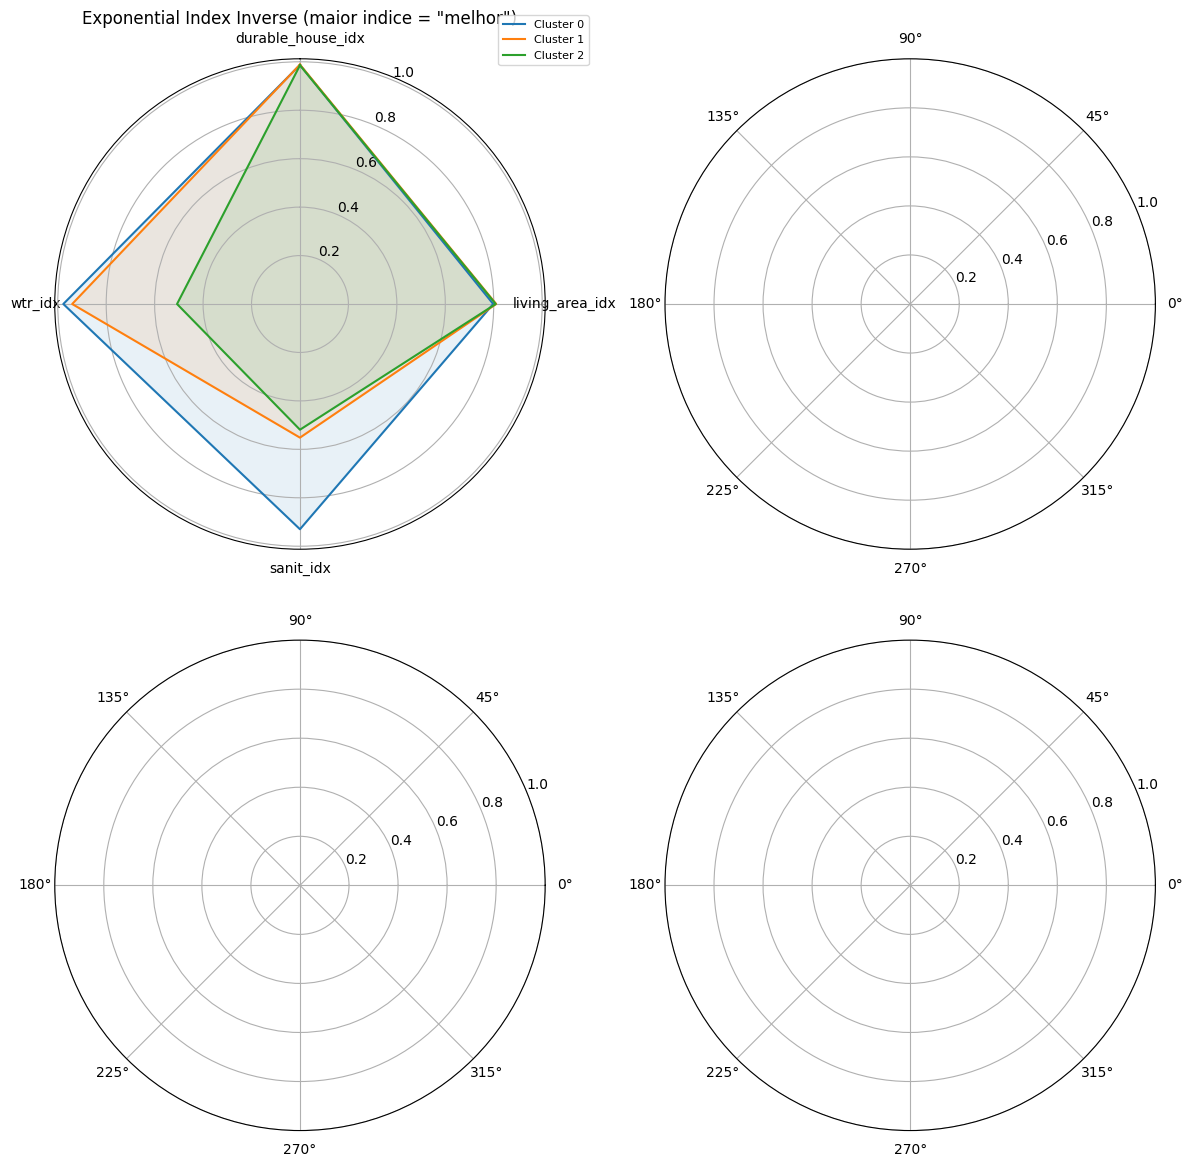

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(polar=True))
dfs = [exp_df_inv]
titles = ['Exponential Index Inverse (maior indice = "melhor")']

for ax, df, title in zip(axs.flat, dfs, titles):
    indices = df.columns.difference(['cluster_3']).tolist()
    num_vars = len(indices)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    cluster_means = df.groupby('cluster_3')[indices].mean()
    for idx, row in cluster_means.iterrows():
        values = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, values, label=f'Cluster {idx}')
        ax.fill(angles, values, alpha=0.1)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), indices)
    ax.set_title(title)
    ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=8)

plt.tight_layout()
plt.show()


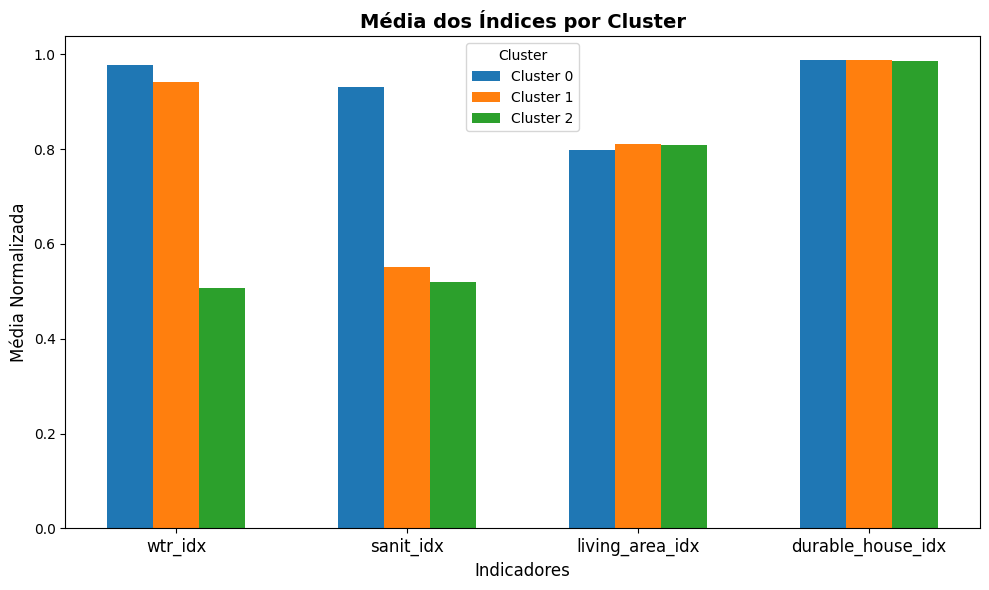

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Selecionando variáveis relevantes e clusters
variables = ['wtr_idx', 'sanit_idx', 'living_area_idx', 'durable_house_idx']
cluster_name = 'cluster_3'

# Compute mean values for each variable by cluster
cluster_means = exp_df_inv.groupby(cluster_name)[variables].mean()

# Dados para o plot
labels = variables
clusters = cluster_means.index.astype(str)
x = np.arange(len(labels))  # wtr_idx, sanit_idx, etc.
width = 0.20  # largura das barras
fig, ax = plt.subplots(figsize=(10, 6))

# Plota cada grupo de cluster
n_clusters = len(clusters)
for i, cluster in enumerate(clusters):
    ax.bar(x + i * width, cluster_means.loc[int(cluster)], width, label=f'Cluster {cluster}')

# Ajustes do eixo x
ax.set_xticks(x + width * (n_clusters-1)/2)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Média Normalizada', fontsize=12)
ax.set_xlabel('Indicadores', fontsize=12)
ax.set_title('Média dos Índices por Cluster', fontsize=14, fontweight='bold')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()


In [20]:
# Cluster number selection: Elbow method and Silhouette score (with twin y-axes)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Select relevant variables
variables = ['wtr_idx', 'sanit_idx', 'living_area_idx', 'durable_house_idx']
X = exp_df_inv[variables].values

inertia = []
silhouette_scores = []
K = range(2, 6)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))




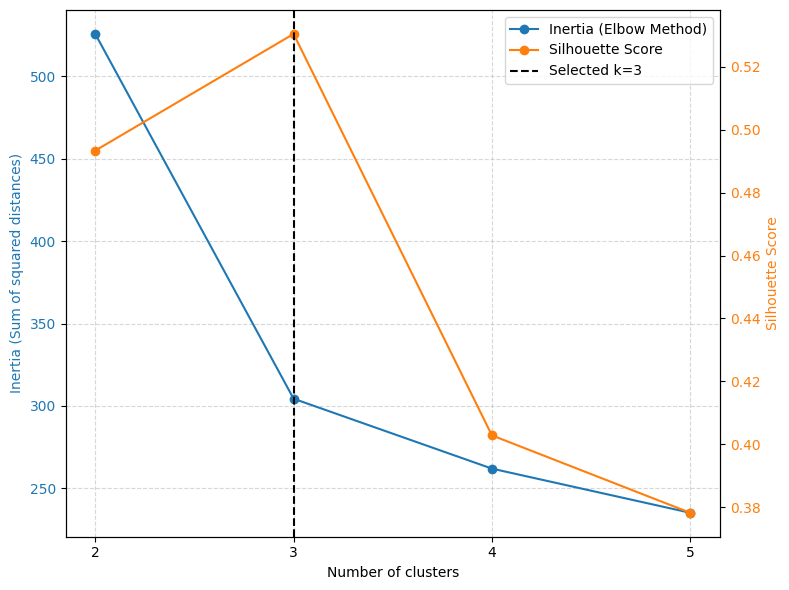

k=2: silhouette score=0.493
k=3: silhouette score=0.530
k=4: silhouette score=0.403
k=5: silhouette score=0.378
k=2: inertia=525.75
k=3: inertia=304.39
k=4: inertia=261.97
k=5: inertia=235.16


In [21]:
plt.figure(figsize=(8, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

# Left y-axis: inertia
lns1 = ax1.plot(K, inertia, marker='o', label='Inertia (Elbow Method)', color='tab:blue')
ax1.set_ylabel('Inertia (Sum of squared distances)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right y-axis: silhouette score
lns2 = ax2.plot(K, silhouette_scores, marker='o', label='Silhouette Score', color='tab:orange')
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Dashed line at k=3 to indicate selected cluster
ax2.axvline(x=3, linestyle='--', color='black', linewidth=1.5, label='Selected k=3')
# ax1.text(3+0.05, ax1.get_ylim()[1]*0.92, 'k=3', color='black', va='top', ha='left', fontsize=10, fontweight='bold')

# Common x-axis (integer steps)
ax1.set_xlabel('Number of clusters')
# plt.title('Elbow Method and Silhouette Score for Cluster Number Selection')
ax1.set_xticks(list(K))

# Combine legends, avoiding duplicate label for "Selected k=3"
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles = handles1 + [h for h, l in zip(handles2, labels2) if l not in labels1]
labels = labels1 + [l for l in labels2 if l not in labels1]
ax1.legend(handles, labels, loc='best')

ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

for k, sil in zip(K, silhouette_scores):
    print(f'k={k}: silhouette score={sil:.3f}')

for k, iner in zip(K, inertia):
    print(f'k={k}: inertia={iner:.2f}')

In [28]:
# Contar registros agrupados por cluster e a porcentagem de cada cluster

cluster_counts = exp_df_inv['cluster_3'].value_counts().sort_index()
cluster_percent = exp_df_inv['cluster_3'].value_counts(normalize=True).sort_index() * 100

summary_df = (
    pd.DataFrame({
        'total': cluster_counts,
        'percent': cluster_percent
    })
)
summary_df.index.name = 'cluster'
summary_df.reset_index(inplace=True)

display(summary_df)


,cluster,total,percent
0,0,6139,49.732663642255346
1,1,4576,37.070641607258587
2,2,1629,13.196694750486065


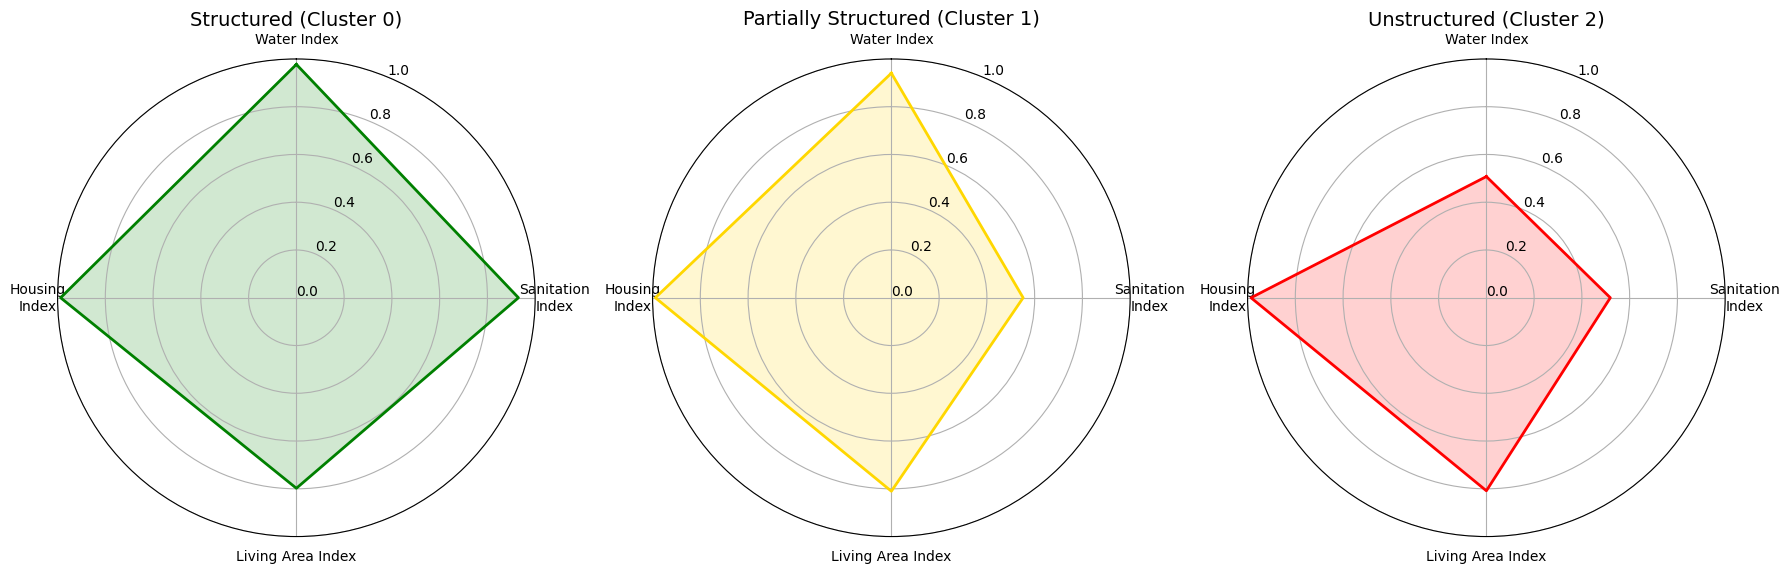

In [46]:
# Agora, gerando 3 radar charts lado a lado, um para cada cluster
# Definir cores específicas para cada cluster
cluster_colors = {0: 'green', 1: 'gold', 2: 'red'}
cluster_labels = {
    0: 'Structured (Cluster 0)', 
    1: 'Partially Structured (Cluster 1)', 
    2: 'Unstructured (Cluster 2)'
}

# Variáveis formatadas para melhor legibilidade no gráfico
display_indices = ['Water Index', 'Sanitation\nIndex', 'Living Area Index', 'Housing\nIndex']
indices = ['wtr_idx', 'sanit_idx', 'living_area_idx', 'durable_house_idx']
num_vars = len(indices)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
cluster_means = exp_df_inv.groupby('cluster_3')[indices].mean()

fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))

for i, (idx, row) in enumerate(cluster_means.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    ax = axs[i]
    color = cluster_colors.get(idx, 'gray')
    ax.plot(angles, values, label=cluster_labels.get(idx, f'Cluster {idx}'), color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.18)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), display_indices)
    # Definindo o mesmo limite de raio e os mesmos labels para todos
    ax.set_ylim(0, 1)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.set_title(cluster_labels.get(idx, f'Cluster {idx}'), fontsize=14)
    # ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.1), fontsize=9)

plt.tight_layout()
plt.show()


In [30]:
cluster_means

,wtr_idx,sanit_idx,living_area_idx,durable_house_idx
cluster_3,,,,
0,0.977080865780787,0.929901818920857,0.797757063687654,0.987140477100865
1,0.940467159334341,0.551726464977779,0.810153973479978,0.988351717768334
2,0.507515293357493,0.519003029207759,0.808278996244795,0.985533218709235
